# RecSys МАГОЛЕГО, ФКН ВШЭ

## Домашняя работа 1: Матричные алгоритмы рекомендаций

### Оценивание и штрафы
Всего заданий: **7**, максимальная оценка — **9 баллов**.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом пользоваться запрещается,даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке (например, лишние циклы, `np.vectorize`, `np.apply_along_axis` и так далее). Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных языковых моделей разрешено только в случае явного указания на это. Необходимо прописать (в соответствующих пунктах, где использовались, либо в начале/конце работы):

- какая языковая модель использовалась
- какие использовались промпты и в каких частях работы
- с какими сложностями вы столкнулись при использовании генеративных моделей, с чем они помогли больше всего
  
Copy-paste ответа генеративной модели запрещается (кроме графиков, но все равно нужно явно прописывать использование)

**Дедлайн: 25.02.2026 23:59 (по МСК)**

**Сдавать сюда: [Классрум](https://classroom.google.com/c/ODQzNjI1ODIzMDEy/a/ODQzNjI1NzMzMjgz/details)**

### О задании
В данном домашнем задании вы реализуете алгоритмы рекомендаций на основе матричных разложений и сравните их между собой на датасете Yahoo! Movies.

P.S Пожалуйста, аккуратно оформляйте графики, ориентироваться можно на [это](https://github.com/esokolov/ml-course-hse/blob/master/2022-fall/seminars/sem02-charts.ipynb). У графиков обязательно должно быть:

- Название
- Подписанные оси
- Легенда, если необходимо (например, если несколько графиков на одном рисунке)
- Все должно быть четко видно и ничего не сливаться
- За некрасивые графики можем снизить баллы

In [1]:
import numpy as np
import pandas as pd
from numba import jit

import matplotlib
matplotlib.rcParams['image.cmap'] = 'jet'
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import ElasticNet

## Структура датасета

Датасет можете скачать по [ссылке](https://drive.google.com/file/d/1PsAL83MQnvQuTpjrNXs8CiPpOeSGcUL-/view?usp=share_link)

Датасет состоит из 6 основных файлов. Все данные представлены в текстовом формате, где колонки разделены символом табуляции `\t`.

### 1. Оценки пользователей
В этих файлах содержатся оценки фильмов пользователей
-  **Файлы:** `ydata-ymovies-user-movie-ratings-train-v1_0` и `ydata-ymovies-user-movie-ratings-test-v1_0`
- **Поля:**
  * User ID
  * Movie ID
  * Rating_13: от 1 (F) до 13 (A+)
  * Rating_5: упрощенная шкала от 1 до 5



### 2. Демография пользователей
Информация про аудиторию

- **Файл:** `ydata-ymovies-user-demographics-v1_0`
- **Поля:**
  * User ID
  * Year of birth
  * Sex (`m`/`f`)

### 3. Описание фильмов
Метаданные фильмов
* **Файл:** `ydata-ymovies-movie-content-descr-v1_0`
* **Что внутри:** Название, синопсис, жанры, режиссеры, актеры, количество наград, средняя оценка критиков и даже ссылки на постеры.
* **Важно:** Если данных нет, стоит заглушка `\N`. Если в поле несколько значений (например, список актеров), они разделены символом `|`.

### 4. Списки соответствия
Файлы `mapping-to-movielens` и `mapping-to-eachmovie` позволяют связать ID фильмов Yahoo с другими популярными датасетами (MovieLens и EachMovie). Это полезно, если вы хотите объединить данные из разных источников


**Задание 0 (0.25 баллов):** Загрузите необходимые данные и постройте `use-item` матрицу интеракций $X$

In [2]:
from scipy import sparse
tr = pd.read_csv("/content/ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz", sep="\t", header=None, usecols=[0, 1, 3], names=["user", "item", "rating"])


In [3]:
tr.head(10)

,user,item,rating
0,1,1800029049,5
1,1,1804857429,4
2,1,1800030906,5
3,1,1800018548,5
4,1,1800256362,4
5,1,1808438656,4
6,1,1807428619,3
7,1,1800373145,4
8,1,1808403329,4
9,1,1804738128,5


In [4]:
u, ui = pd.factorize(tr["user"], sort=True)
i, ii = pd.factorize(tr["item"], sort=True)
X = sparse.csr_matrix((tr["rating"].to_numpy(), (u, i)), shape=(ui.size, ii.size))
X.shape

(7642, 11916)

## Метрики

Пусть
- $K$ - длина списка рекомендаций (например, 10)
- $Rec_K$ - список из $K$ рекомендованных объектов
- $Rel$ — множество всех релевантных объектов для пользователя
- $rel_i$ - релевантность объекта на позиции $i$ (обычно 1, если объект релевантен, и 0, если нет)

В качестве метрик рекомендаций возьмем:

- $Precision@K = \frac{|Rec_K \cap Rel|}{K}$
  
- $Recall@K = \frac{|Rec_K \cap Rel|}{|Rel|}$

- $AP@K = \frac{1}{\min(K, |Rel|)} \sum\limits_{i = 1}^K rel_i \cdot \left(\frac{|Rec_i \cap Rel|}{i}\right)$
  
- $NDCG@K$:
  
  - $DCG@K = \sum\limits_{i = 1}^K \frac{rel_i}{\log_2(i + 1)}$
  
  - $IDCG@K = \sum\limits_{i = 1}^{\min(K, |Rel|)} \frac{1}{\log_2(i + 1)}$
  
  - $NDCG@K = \frac{DCG@K}{IDCG@K}$

**Задание 1 (0.5 баллов):** Реализуйте вышеперечисленные метрики для одного пользователя


In [5]:
def precision_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10
    ) -> float:
    rl = recommended_list[:k]
    if rl.size == 0:
        return 0.0
    rel = np.unique(relevant_items)
    return np.isin(rl, rel).mean()


def recall_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10
    ) -> float:
    rel = np.unique(relevant_items)
    if rel.size == 0:
        return 0.0
    rl = recommended_list[:k]
    return np.isin(rl, rel).sum() / rel.size

def ap_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10
    ) -> float:
    rl = recommended_list[:k]
    rel = np.unique(relevant_items)
    if rl.size == 0 or rel.size == 0:
        return 0.0

    hit = np.isin(rl, rel)
    cs = np.cumsum(hit)
    pr = cs/(np.arange(rl.size) + 1.0)

    d = min(k, rel.size)
    return float((hit * pr).sum() / d)

def ndcg_at_k(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10
    ) -> float:
    rl = recommended_list[:k]
    rel = np.unique(relevant_items)
    if rl.size == 0 or rel.size == 0:
        return 0.0

    hit = np.isin(rl, rel)
    den = np.log2(np.arange(rl.size) + 2.0)
    dcg = float((hit / den).sum())

    m = min(k, rel.size)
    idcg = float((1.0 / np.log2(np.arange(m) + 2.0)).sum())

    return 0.0 if idcg == 0.0 else dcg / idcg


In [6]:
def evaluate_recommender(
    recommended_list: np.ndarray,
    relevant_items: np.ndarray,
    k: int = 10
    ) -> dict:
    return {
        "precision@k": precision_at_k(recommended_list, relevant_items, k),
        "recall@k": recall_at_k(recommended_list, relevant_items, k),
        "ap@k": ap_at_k(recommended_list, relevant_items, k),
        "ndcg@k": ndcg_at_k(recommended_list, relevant_items, k),
    }


## Baseline

Начнем с двух базовых алгоритмов рекомендаций:

- Случайный: рекомендуем случайные $K$ фильмов
- Топ популярных: рекомендуем $K$ самых популярных фильмов

**Задание 2 (0.25 баллов):** Имплементируйте алгоритмы рекомендаций выше и провалидируйте на тестовом датасете помощью с `evaluate_recommender`. Сделайте график метрик в зависимости от $K$ (и для всех методов ниже так же нужно сделать)

**Ответ:**
Как видим из графиков сравнения рандомно рекомендованных фильмов и самых популярных фильмов, по метрикам явно превосходит рекомендация самых популярных фильмов. Качество, по всем метрикам, случайных фильмов около нулевая на всем рассматриваемом диапазоне К

In [7]:
class RandomRecommender:
    def __init__(self, k: int = 10) -> None:
        self.k = k

    def fit(self, X) -> None:
        self.n_items = X.shape[1]

    def predict(self, user_seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        s = np.unique(user_seen_items)
        mask = np.ones(self.n_items)
        mask[s] = False
        pool = np.flatnonzero(mask)
        return np.random.choice(pool, size=min(k, pool.size), replace=False)


In [8]:
class MostPopularRecommender:
    def __init__(self, train_df: pd.DataFrame) -> None:
        self.pop = train_df["i"].value_counts().index.to_numpy(dtype=np.int64)

    def predict(self, user_seen_items: np.ndarray, k: int = 10) -> np.ndarray:
        s = np.unique(user_seen_items)
        m = np.isin(self.pop, s, invert=True)
        return self.pop[m][:k]


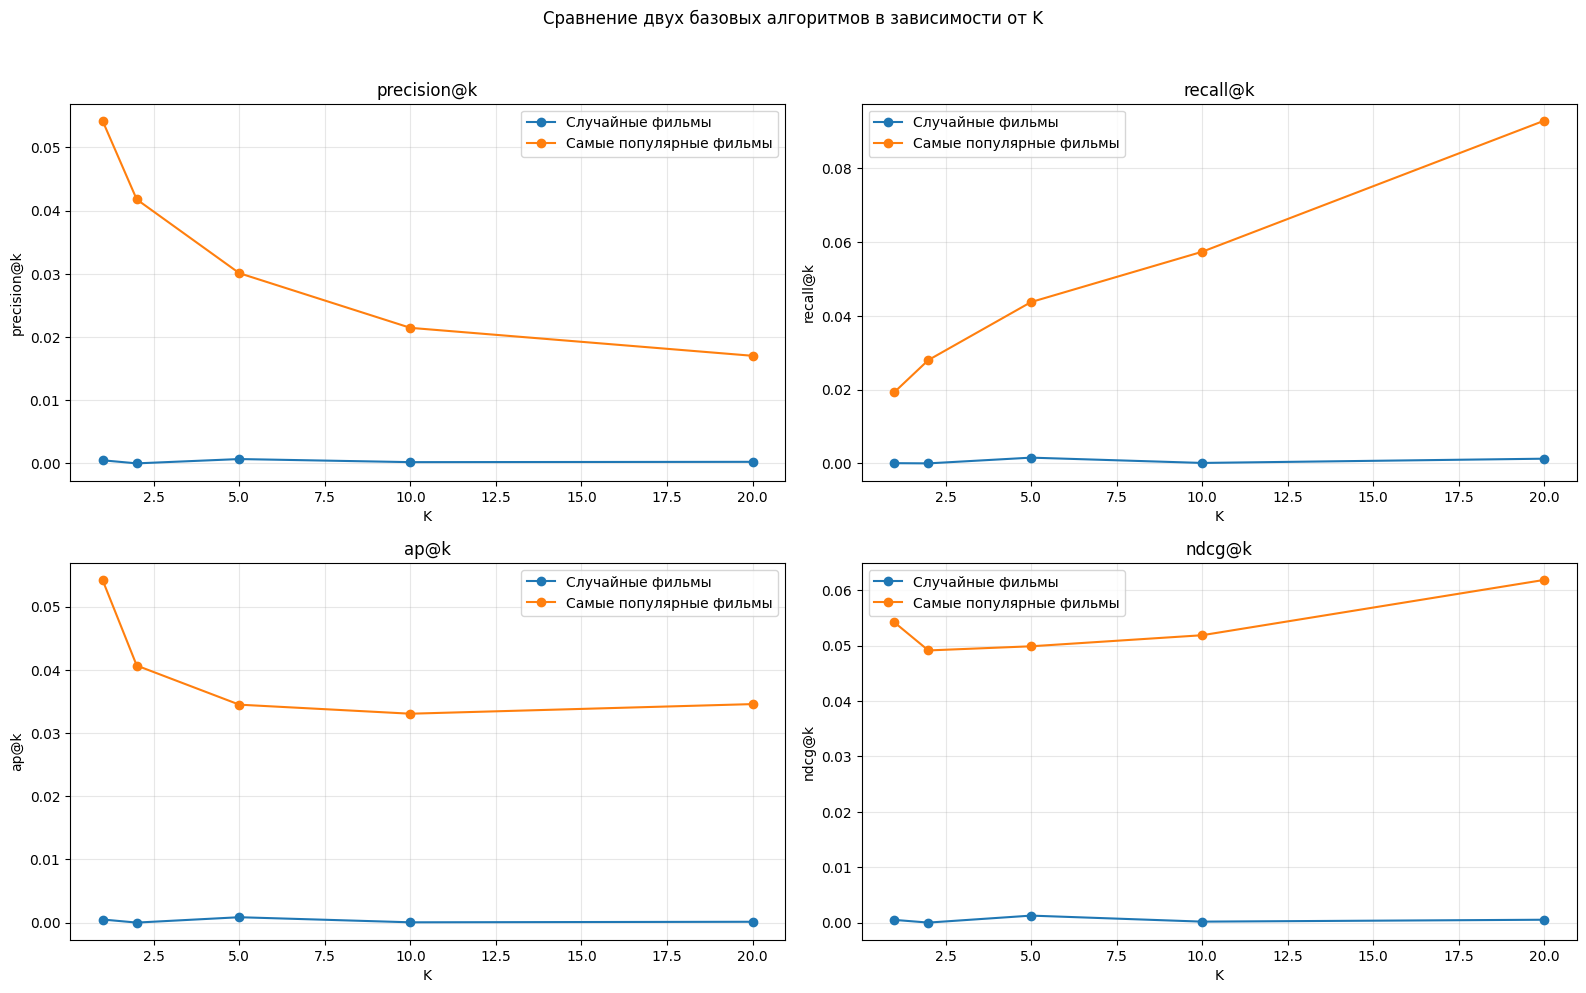

In [9]:
tr = pd.read_csv("/content/ydata-ymovies-user-movie-ratings-train-v1_0.txt.gz",
                 sep="\t", header=None, usecols=[0, 1, 3], names=["user", "item", "rating"])
te = pd.read_csv("/content/ydata-ymovies-user-movie-ratings-test-v1_0.txt.gz",
                 sep="\t", header=None, usecols=[0, 1, 3], names=["user", "item", "rating"])

u = np.sort(tr["user"].unique())
i = np.sort(tr["item"].unique())
um = pd.Series(np.arange(u.size), index=u)
im = pd.Series(np.arange(i.size), index=i)

tr["u"] = um.loc[tr["user"]].to_numpy()
tr["i"] = im.loc[tr["item"]].to_numpy()
te = te[te["item"].isin(im.index)]
te["u"] = um.loc[te["user"]].to_numpy()
te["i"] = im.loc[te["item"]].to_numpy()

X_bin = X.copy()
X_bin.data = (X_bin.data >= 4).astype(np.float32)
X_bin.eliminate_zeros()
X_any = X.copy()
X_any.data = np.ones_like(X_any.data, dtype=np.float32)

seen = tr.groupby("u")["i"].apply(lambda x: x.to_numpy())
rtarget = 4.0
rel = te[te["rating"] >= rtarget].groupby("u")["i"].apply(lambda x: x.to_numpy())
rel = rel[rel.apply(len) > 0]

rr = RandomRecommender()
rr.fit(X)
mp = MostPopularRecommender(tr)

ks = np.array([1, 2, 5, 10, 20])
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]
res = {(met, a): [] for met in ms for a in ["random", "popular"]}

for k in ks:
    s_pr = {met: 0.0 for met in ms}; s_rr = {met: 0.0 for met in ms}
    c = 0
    for uu, r_it in rel.items():
        s_it = seen.get(uu, np.array([]))
        a = evaluate_recommender(rr.predict(s_it, k), r_it, k)
        b = evaluate_recommender(mp.predict(s_it, k), r_it, k)
        for met in ms:
            s_rr[met] += a[met]
            s_pr[met] += b[met]
        c += 1
    for met in ms:
        res[(met, "random")].append(s_rr[met] / c)
        res[(met, "popular")].append(s_pr[met] / c)

fig, ax = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
ax = ax.ravel()
for j, met in enumerate(ms):
    ax[j].plot(ks, res[(met, "random")], marker="o", label="Случайные фильмы")
    ax[j].plot(ks, res[(met, "popular")], marker="o", label="Самые популярные фильмы")
    ax[j].set_title(met)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(met)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Сравнение двух базовых алгоритмов в зависимости от K", y=1.02)
fig.tight_layout(pad=1.2, rect=(0, 0.03, 1, 1))
plt.show()


Для построения графиков использовался ассистент Cursor.
Промпт: «Напиши код для построения четырёх графиков precision@k, recall@k, ap@k и ndcg@k для сравнения алгоритмов в зависимости от K».
Остальные графики строила по этому шаблону. Сложностей не возникло, код сгенерировался рабочим


## SVD (Singular Value Decomposition)

Давайте вспомним метод SVD

SVD в контексте рекомендательных систем часто формулируется как задача оптимизации матричной факторизации, чтобы справиться с разреженностью матрицы взаимодействий $R$

Вместо классического SVD, требующего полной матрицы, мы ищем низкоранговое приближение $R \approx P Q^T$, где $P$ и $Q$ — матрицы скрытых факторов пользователей и объектов

**Задача оптимизации:**
Мы минимизируем ошибку только по наблюдаемым оценкам $(u, i) \in \Omega$ с добавлением L2-регуляризации для предотвращения переобучения:
$$\min_{P,Q} \sum_{(u,i) \in \Omega} (R_{ui} - p_u^T q_i)^2 + \lambda (\|p_u\|^2 + \|q_i\|^2)$$

**Алгоритм обучения:**
Для решения этой задачи обычно используется стохастический градиентный спуск (SGD). Правила обновления весов для каждого наблюдения $R_{ui}$ выглядят следующим образом:
$$p_u \leftarrow p_u + \eta (e_{ui} q_i - \lambda p_u)$$
$$q_i \leftarrow q_i + \eta (e_{ui} p_u - \lambda q_i)$$

где $e_{ui} = R_{ui} - p_u^T q_i$ — ошибка предсказания

**Задание 3 (2 балла):** Реализуйте алгоритм рекомендаций на основе SVD. Лучше ли по сравнению с бейзлайном? Проанализируйте ближайших соседей в пространстве эмбеддингов. Переберите несколько размерностей латентного пространства

**Ответ:**
Если посмотреть на общие графики сравнения SVD c baseline моделями, то SVD, так же как и рекомендация самых популярных фильмов, явно лучше рандомных рекомендаций. SVD по сравнению с рекомендациями самых популярных фильмов , показывает более высокое значение recall@K начиная примерно с  К = 6, но при этом ap@K ниже на всём рассмотренном диапазоне К, precision@k и ndcg@k у SVD и полулярных фильмов примерно одинаковые после К=7, а при К < 7 наиболее популярные фильмы опережают SVD

In [10]:
class SVDRecommender:
    def __init__(self, hidden_dim: int = 50) -> None:
        self.d = hidden_dim
        self.svd = TruncatedSVD(n_components=self.d, random_state=42)

    def fit(self, X) -> None:
        self.p = self.svd.fit_transform(X)
        self.q = self.svd.components_.T

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.q @ self.q.T


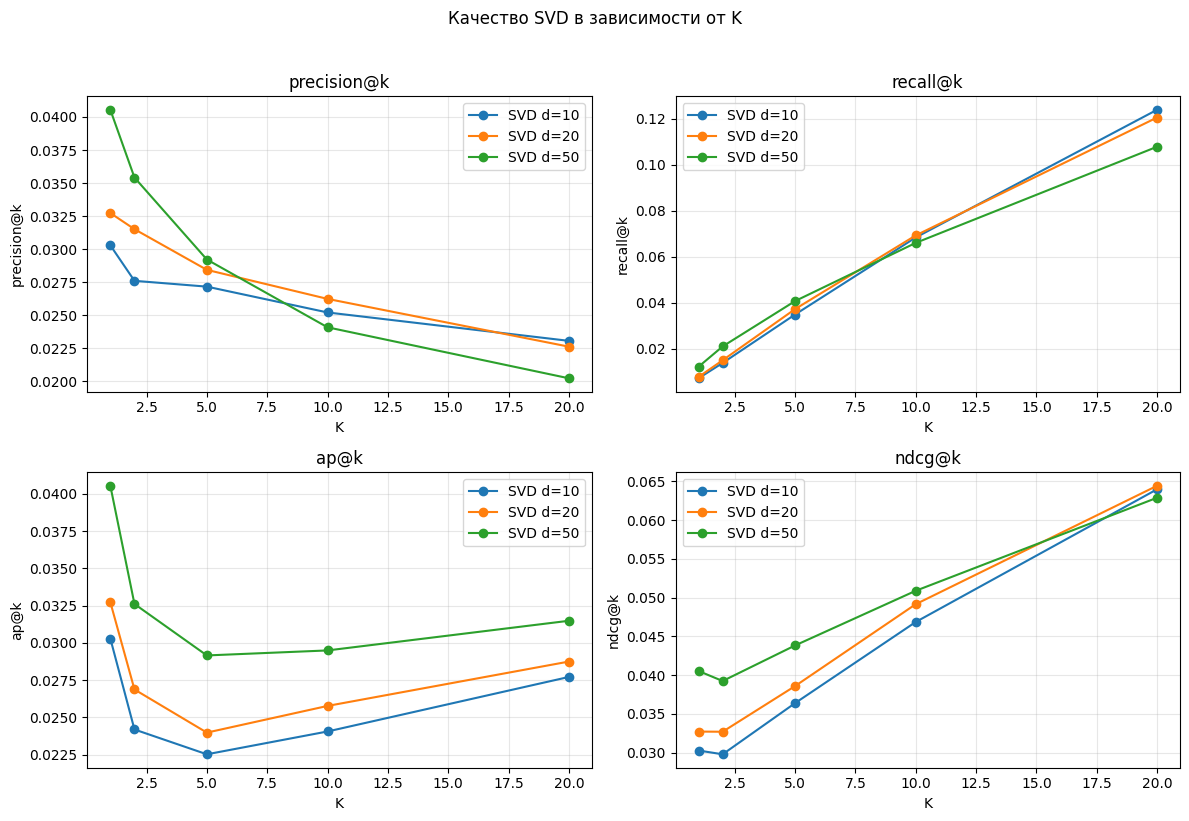

In [11]:
ds = [10, 20, 50]
ks = [1, 2, 5, 10, 20]
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

m = {}
for d in ds:
    r = SVDRecommender(hidden_dim=d)
    r.fit(X)
    sc = r.p @ r.q.T
    sc[tr.u.to_numpy(), tr.i.to_numpy()] = -np.inf

    rr = {mm: [] for mm in ms}
    for k in ks:
        s = {mm: 0.0 for mm in ms}
        c = 0
        for uu, r_it in rel.items():
            idx = np.argpartition(-sc[uu], k - 1)[:k]
            idx = idx[np.argsort(-sc[uu, idx])]
            a = evaluate_recommender(idx, r_it, k)
            for mm in ms:
                s[mm] += a[mm]
            c += 1
        for mm in ms:
            rr[mm].append(s[mm] / c)
    m[d] = rr

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    for d in ds:
        ax[j].plot(ks, m[d][mm], marker="o", label=f"SVD d={d}")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Качество SVD в зависимости от K", y=1.02)
fig.tight_layout()
plt.show()


Как видно из графиков сравнения различных размеров латентного пространства, качество моделей в среднем примерно одинаковое, за исключением метрики AP@k. Для размерности d=50 качество на этой метрике заметно выше.


**Сраванение метрик качесва Baseline и SVD**

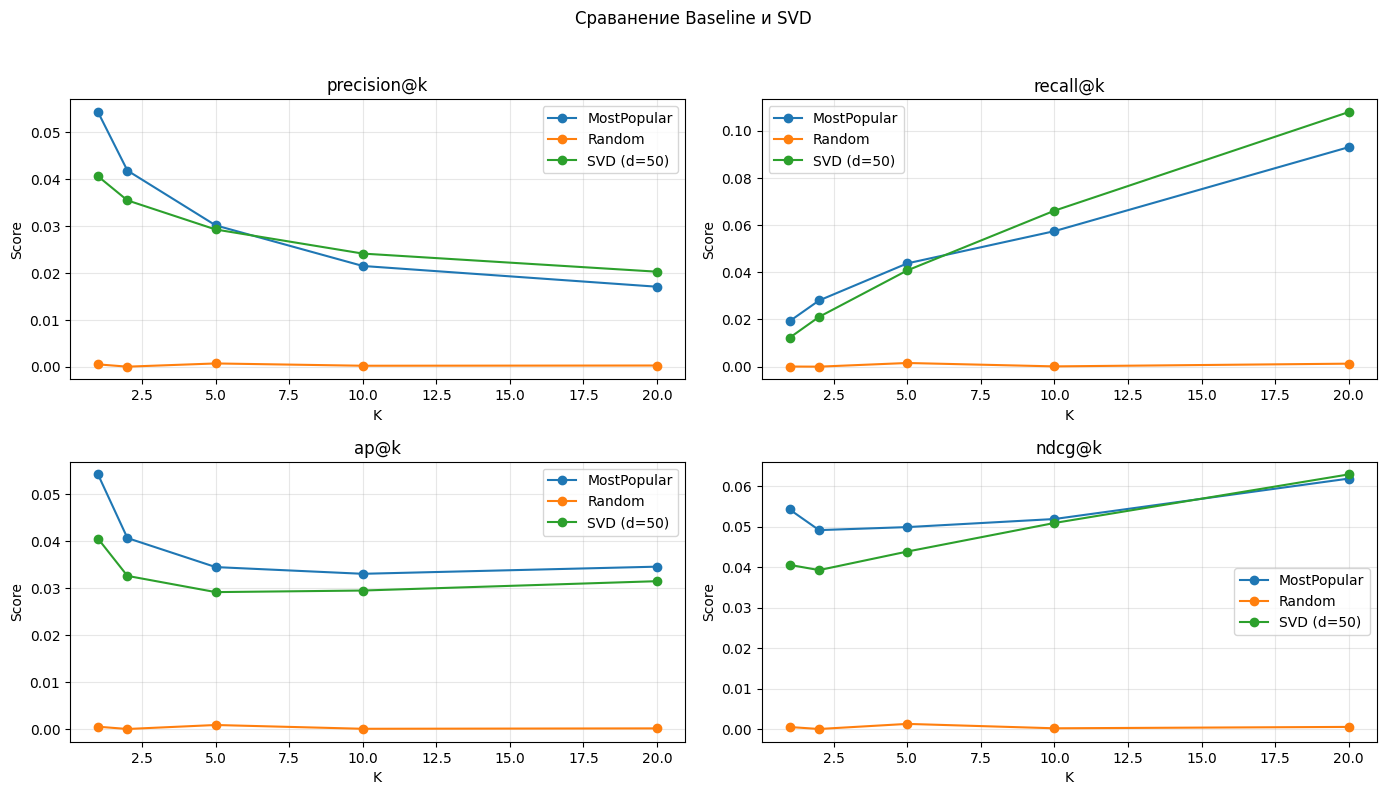

In [12]:
ks_plot = np.array([1, 2, 5, 10, 20])
ms_plot = ["precision@k", "recall@k", "ap@k", "ndcg@k"]

fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms_plot):
    ax[j].plot(ks_plot, res[(mm, "popular")], "-", marker="o", label="MostPopular")
    ax[j].plot(ks_plot, res[(mm, "random")], "-", marker="o", label="Random")
    ax[j].plot(ks_plot, m[50][mm], "-", marker="o", label="SVD (d=50)")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel("Score")
    ax[j].grid(True, alpha=0.3)
    ax[j].legend(loc="best")
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Сраванение Baseline и SVD", y=1.02)
fig.tight_layout(pad=1.2, rect=(0, 0.03, 1, 1))
plt.show()

**Анализ ближайших соседей в пространстве эмбеддингов SVD**


In [13]:
r_svd = SVDRecommender(hidden_dim=20)
r_svd.fit(X)

Q = r_svd.q
popular_item = tr["i"].value_counts().index[0]
item_vec = Q[popular_item]
scores = Q @ item_vec
scores[popular_item] = -np.inf
neighbors = np.argsort(-scores)[:5]


In [14]:
ids = i[[popular_item, *neighbors]].astype(int)
descr = pd.read_csv("/content/ydata-ymovies-movie-content-descr-v1_0.txt.gz", sep="\t", usecols=[0, 1], header=None, encoding="latin-1", on_bad_lines="skip")
descr.columns = ["id", "title"]
descr = descr[pd.to_numeric(descr["id"], errors="coerce").notna() & (descr["title"].astype(str) != "\\N")]
id_to_title = dict(zip(descr["id"].astype(int), descr["title"].str.strip()))

sims = np.r_[item_vec @ item_vec, scores[neighbors]]
for lab, yid, sim in zip(["Исходный"] + [f"{j}" for j in range(1, 6)], ids, sims):
    print(f"  {lab}: {id_to_title.get(yid, yid)}  {sim:.3f}")

  Исходный: Pirates of the Caribbean: The Curse of the Black Pearl (2003)  0.940
  1: The League of Extraordinary Gentlemen (2003)  0.089
  2: Sleepy Hollow (1999)  0.047
  3: The Italian Job (2003)  0.047
  4: Edward Scissorhands (1990)  0.044
  5: Once Upon A Time In Mexico (2003)  0.038


Ближайшие соседи ищутся по скалярному произведению эмбедингов. Большинство(3 из 5) фильмов вышли в 2003 году,то есть  вполне возможно в 2003 году зритетелей которые сморели "Пиратов карибского моря" интересовали именно такие фильмы. А так же жанры примерно совпалают приключеня с экшеном

В данном анализе использовался ассистент Cursor. Промт: "Найти ближайших 5 соседей и вывести названия фильмов и их скалярную близость." Проблема была в том, что не смогла самостоятельно извлечь названия ближайших 5 фильмов. Модель не могла прочитать корретктно данные . Названия не извлекались из-за проблем с кодировкой файла. Ассистент помог найти эту проблему и извлеч названия фильмов, нужно было указать encoding="latin-1". После этого, код заработал



## SLIM (Sparse Linear Methods)

Хотя SVD и матричная факторизация являются фундаментом рекомендательных систем, у них есть свои ограничения. Латентные факторы (скрытые признаки) часто сложны для интерпретации, а качество рекомендаций может страдать на очень разреженных данных, где классические меры сходства нестабильны

SLIM предлагает альтернативный взгляд: вместо проекции в скрытое пространство, давайте выучим матрицу связей **Item-Item** напрямую из данных. Это позволяет явно моделировать распространение интереса от просмотренных товаров к рекомендованным

SLIM — это линейная модель, которая обучается находить матрицу **разреженных** коэффициентов $B$ для прямого предсказания оценок на основе истории взаимодействий. Идея заключается в том, что рекомендации генерируются путем распространения интереса между похожими объектами

**Принцип работы:**
Предсказанный скор для пользователя рассчитывается как $\hat{X} = X B$, где $X$ — вектор истории пользователя

**Задача оптимизации:**
Обучение сводится к задаче ElasticNet-регрессии. Мы минимизируем следующую функцию потерь:
$$\mathcal{L}(B) = \frac{1}{2} \| X - X B \|_F^2 + \lambda_1 \| B \|_1 + \frac{\lambda_2}{2} \| B \|_F^2$$

**Ограничения (Constraints):**
Модель накладывает два важных ограничения:
1.  $B_{ii} = 0$: Диагональные элементы должны быть равны нулю (чтобы исключить тривиальное решение $B=I$, когда предмет рекомендует сам себя)
2.  $B_{ij} \ge 0$: Веса должны быть неотрицательными, что обеспечивает интерпретируемость (положительная связь между предметами)

**Преимущества:**
* Изучает отношения "Item-Item" напрямую из данных
* Создает разреженную и интерпретируемую матрицу

**Задание 4 (2 балла):** Теперь реализуем модель SLIM. Все так же нужно сравнить с предыдущими моделями. Проанализируйте item-item коэффициенты. Получается ли матрица разреженной?

**Ответ:**  Для небольших K < 5 SLIM имеет примерно такое же поведение как наиболее популярные рекомендации , на малых К он опережает SVD, то есть SLIM хорошо выделяет несколько лучших рекомендаций в начале списка, но хуже покрывает весь набор релевантных товаров. При K > 5 SLIM проигрывает SVD и наиболее популярным фильмам

Матрица B оказывается очень разреженной плотность 2.61e-07 (почти все элементы нули)


In [15]:
class SLIMRecommender:
    def __init__(self, l1_ratio: float = 0.1, alpha: float = 1.0) -> None:
        self.l1_ratio = l1_ratio
        self.alpha = alpha
        self.W = None

    def fit(self, X) -> None:
        X = X.tocsc() if sparse.issparse(X) else sparse.csc_matrix(X)
        n = X.shape[1]
        r, c, v = [], [], []
        m = ElasticNet(alpha=self.alpha, l1_ratio=self.l1_ratio,
                       fit_intercept=False, positive=True,
                       selection="random", max_iter=1000, tol=1e-4)
        for j in range(n):
            y = X[:, j].toarray().ravel()
            m.fit(X, y)
            w = m.coef_
            w[j] = 0.0
            nz = w.nonzero()[0]
            if nz.size:
                r.append(nz)
                c.append(np.full(nz.size, j))
                v.append(w[nz])
        if not v:
            self.W = sparse.csr_matrix((n, n))
        else:
            r = np.concatenate(r)
            c = np.concatenate(c)
            v = np.concatenate(v)
            self.W = sparse.csr_matrix((v, (r, c)), shape=(n, n))

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.sparse_enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of ite

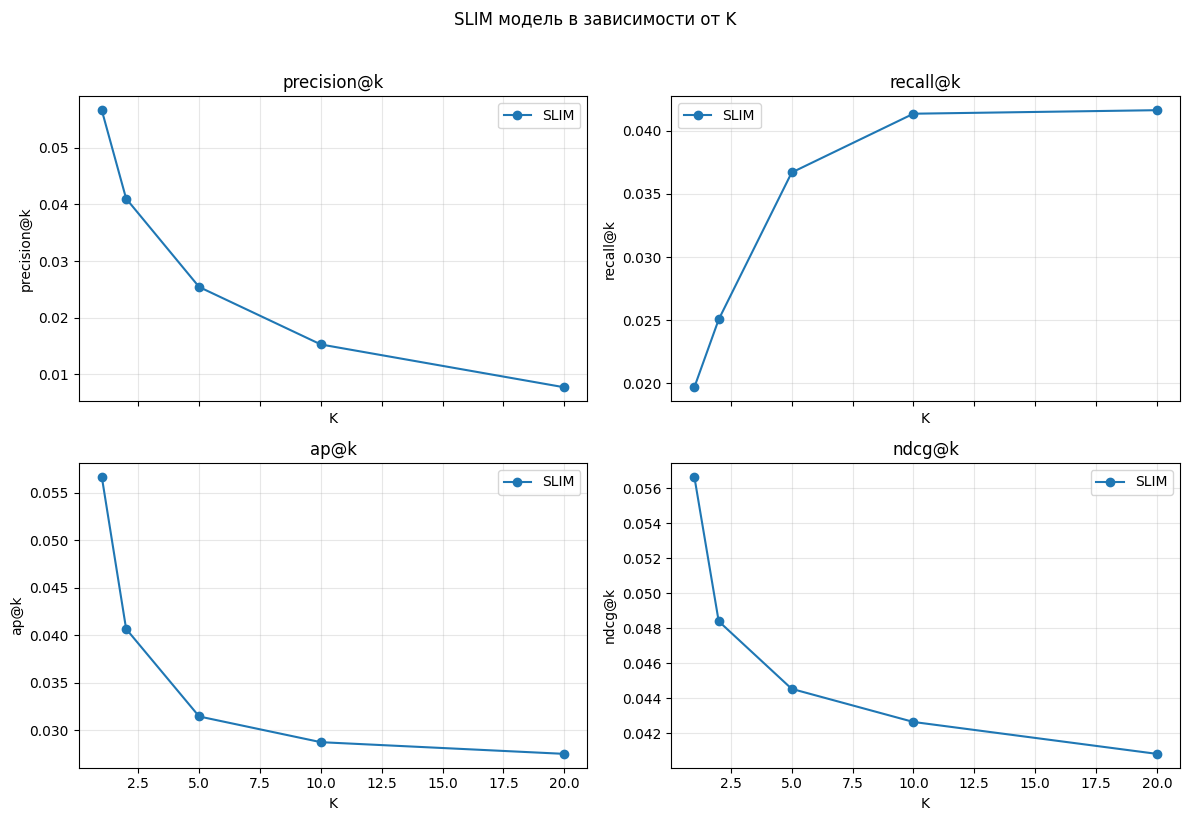

((11916, 11916), 37, 2.605797931385199e-07)

In [16]:
sl = SLIMRecommender(l1_ratio=0.1, alpha=1.0)
sl.fit(X_bin)
sc = (X_bin @ sl.W).tocsr()
sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9
sc.eliminate_zeros()
ks = [1, 2, 5, 10, 20]
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]
rr = {mm: [] for mm in ms}
for k in ks:
    s = {mm: 0.0 for mm in ms}
    c0 = 0
    for uu, r_it in rel.items():
        su = sc.getrow(uu).toarray().ravel()
        idx = np.argpartition(-su, k - 1)[:k]
        idx = idx[np.argsort(-su[idx])]
        a = evaluate_recommender(idx, r_it, k)
        for mm in ms:
            s[mm] += a[mm]
        c0 += 1
    for mm in ms:
        rr[mm].append(s[mm] / c0)

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, rr[mm], marker="o", label="SLIM")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("SLIM модель в зависимости от K", y=1.02)
fig.tight_layout()
plt.show()
slim_results = {k: list(v) for k, v in rr.items()}
sl.W.shape, sl.W.nnz, sl.W.nnz / (sl.W.shape[0] * sl.W.shape[1])


**Сравнение SLIM с бейзлайном и SVD**

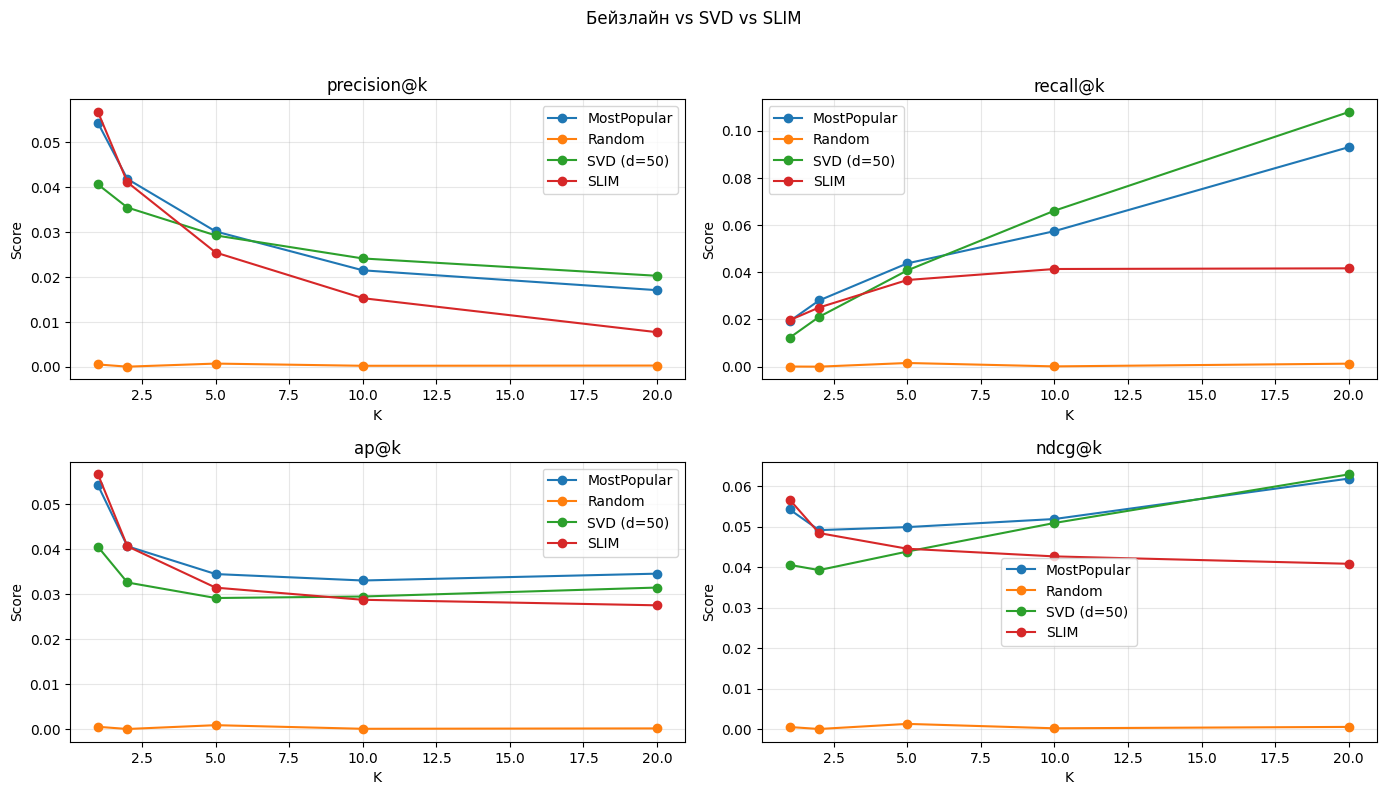

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, res[(mm, "popular")], "-", marker="o", label="MostPopular")
    ax[j].plot(ks, res[(mm, "random")], "-", marker="o", label="Random")
    ax[j].plot(ks, m[50][mm], "-", marker="o", label="SVD (d=50)")
    ax[j].plot(ks, slim_results[mm], "-", marker="o", label="SLIM")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel("Score")
    ax[j].grid(True, alpha=0.3)
    ax[j].legend(loc="best")
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Бейзлайн vs SVD vs SLIM", y=1.02)
fig.tight_layout(pad=1.2, rect=(0, 0.03, 1, 1))
plt.show()

**Проверка на разреженность матрицы**

Плотность: 2.61e-07


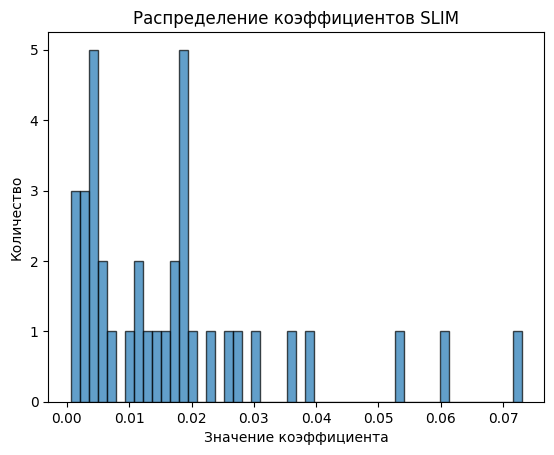

In [18]:
print(f"Плотность: {sl.W.nnz / (sl.W.shape[0] ** 2):.2e}")

plt.hist(sl.W.data, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Значение коэффициента")
plt.ylabel("Количество")
plt.title("Распределение коэффициентов SLIM")
plt.show()

## EASE (Embarrassingly Shallow AutoEncoders)

SLIM создает качественную и разреженную матрицу, но платит за это высокую цену в производительности. Обучение модели требует итеративного решения множества задач регрессии (Lasso/ElasticNet), что вычислительно дорого и медленно. Это ограничивает масштабируемость метода на больших каталогах

EASE решает эту проблему радикально. Убрав L1-регуляризацию и ограничение на неотрицательность весов, мы можем свести задачу к аналитической формуле. Это позволяет получить точное решение за один шаг, избегая долгого градиентного спуска.

EASE — это упрощенный линейный автоэнкодер, который, в отличие от SLIM, имеет замкнутое аналитическое решение и не требует итеративного обучения (градиентного спуска)

**Задача оптимизации:**
Функция потерь похожа на SLIM, но используется только L2-регуляризация, и убрано ограничение на неотрицательность весов (остается только ограничение на нулевую диагональ):
$$\min_{B} \frac{1}{2} \| X - X B \|_F^2 + \frac{\lambda}{2} \| B \|_F^2, \quad \text{при } \text{diag}(B) = 0$$

**Аналитическое решение:**
Решение вычисляется через обращение матрицы Грама. Пусть $H = (X^T X + \lambda I)^{-1}$. Тогда матрица весов $B$ вычисляется по формуле:

$$B_{ij} = \begin{cases} 0, & \text{если } i = j \\ -\frac{H_{ij}}{H_{jj}}, & \text{если } i \neq j \end{cases}$$

**Особенности:**
Метод очень быстр в обучении для матриц среднего размера и часто показывает качество лучше, чем сложные нейросети, но матрица $B$ получается плотной (dense), что затрудняет масштабирование

**Задание 5 (2 балла):** Реализуем EASE алгоритм. Продолжаем сравнивать с предыдущими методами. Насколько быстрее SLIM?

**Ответ:** В сравнении c предыдущими моделями EASE лучшая, выше всех остальных моделей по precision@k, recall@k, ap@k и ndcg@k. Хорошо ищет самые релевантные объекты в начале списка и лучше остальных покрывает множество релевантных фильмов. На малых К  EASE ведет себя так же как и SLIM. Получаентся EASE более стабилен при увеличении K, чем SLIM.




In [19]:
class EASERecommender:
    def __init__(self, l2_lambda: float) -> None:
        self.l2_lambda = l2_lambda
        self.W = None

    def fit(self, X) -> None:
        nitem = X.shape[1]
        if sparse.issparse(X):
            XtX = (X.T @ X).toarray()
        else:
            XtX = X.T @ X
        amat = XtX + self.l2_lambda * np.eye(nitem)
        hmat = np.linalg.inv(amat)
        bmat = -hmat
        for idx in range(nitem):
            bmat[idx, idx] = 0.0
            bmat[:, idx] = bmat[:, idx] / hmat[idx, idx]
        self.W = bmat

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


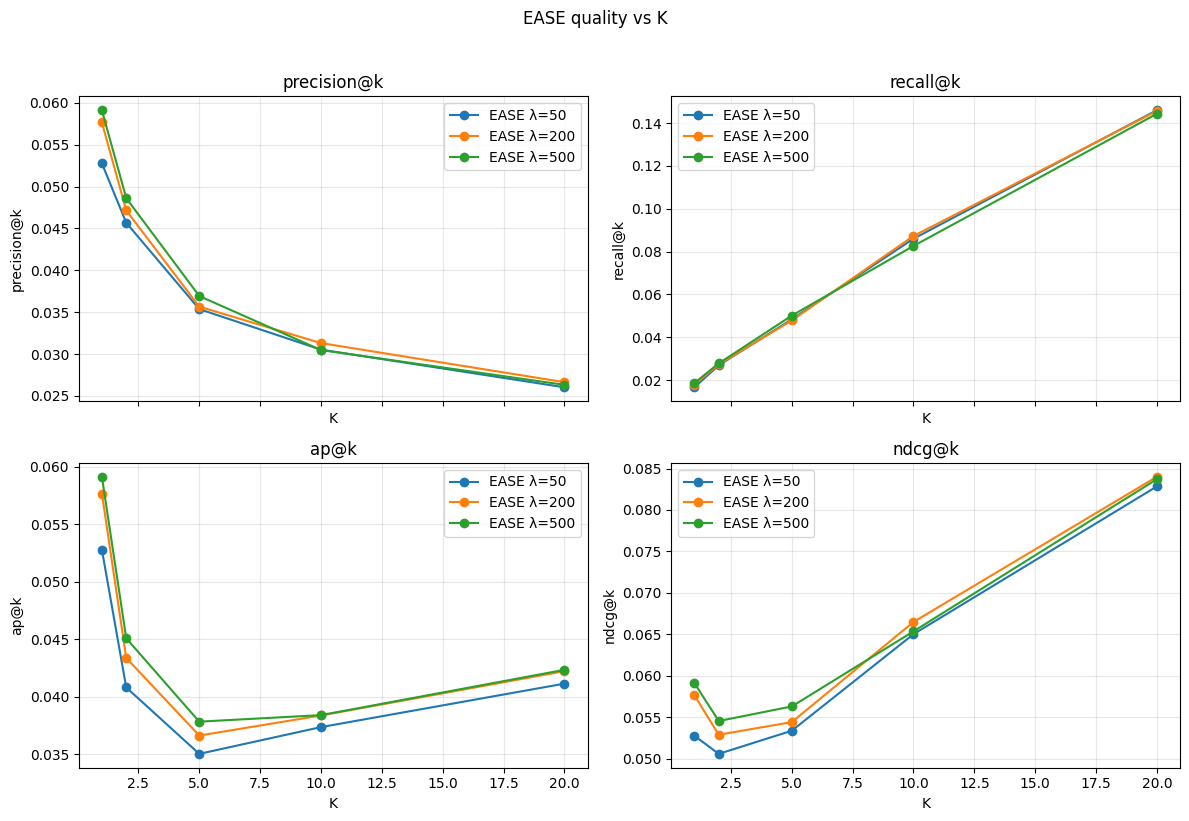

In [20]:
ls = [50, 200, 500]
ks = np.array([1, 2, 5, 10, 20])
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]
ease = {}
for l2 in ls:
    r = EASERecommender(l2_lambda=l2)
    r.fit(X_bin)
    sc = X_bin @ r.W
    sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9
    rr = {mm: [] for mm in ms}
    for k in ks:
        s = {mm: 0.0 for mm in ms}
        c0 = 0
        for uu, r_it in rel.items():
            su = sc[uu]
            idx = np.argpartition(-su, k - 1)[:k]
            idx = idx[np.argsort(-su[idx])]
            a = evaluate_recommender(idx, r_it, k)
            for mm in ms:
                s[mm] += a[mm]
            c0 += 1
        for mm in ms:
            rr[mm].append(s[mm] / c0)
    ease[l2] = rr

fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    for l2 in ls:
        ax[j].plot(ks, ease[l2][mm], marker="o", label=f"EASE λ={l2:g}")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
fig.suptitle("EASE quality vs K", y=1.02)
fig.tight_layout()
plt.show()


По графикам видно, что все три значения λ 50, 200, 500 ведут себя почти одинаково по всем метрикам. Кривые почти совпадают, различия небольшие. В целом можно сделать вывод, что качество EASE слабо зависит от λ в этом диапазоне, модель ведёт себя устойчиво по отношению к регуляризации.

**Сравнение EASE, SLIM, SVD и Baseline**

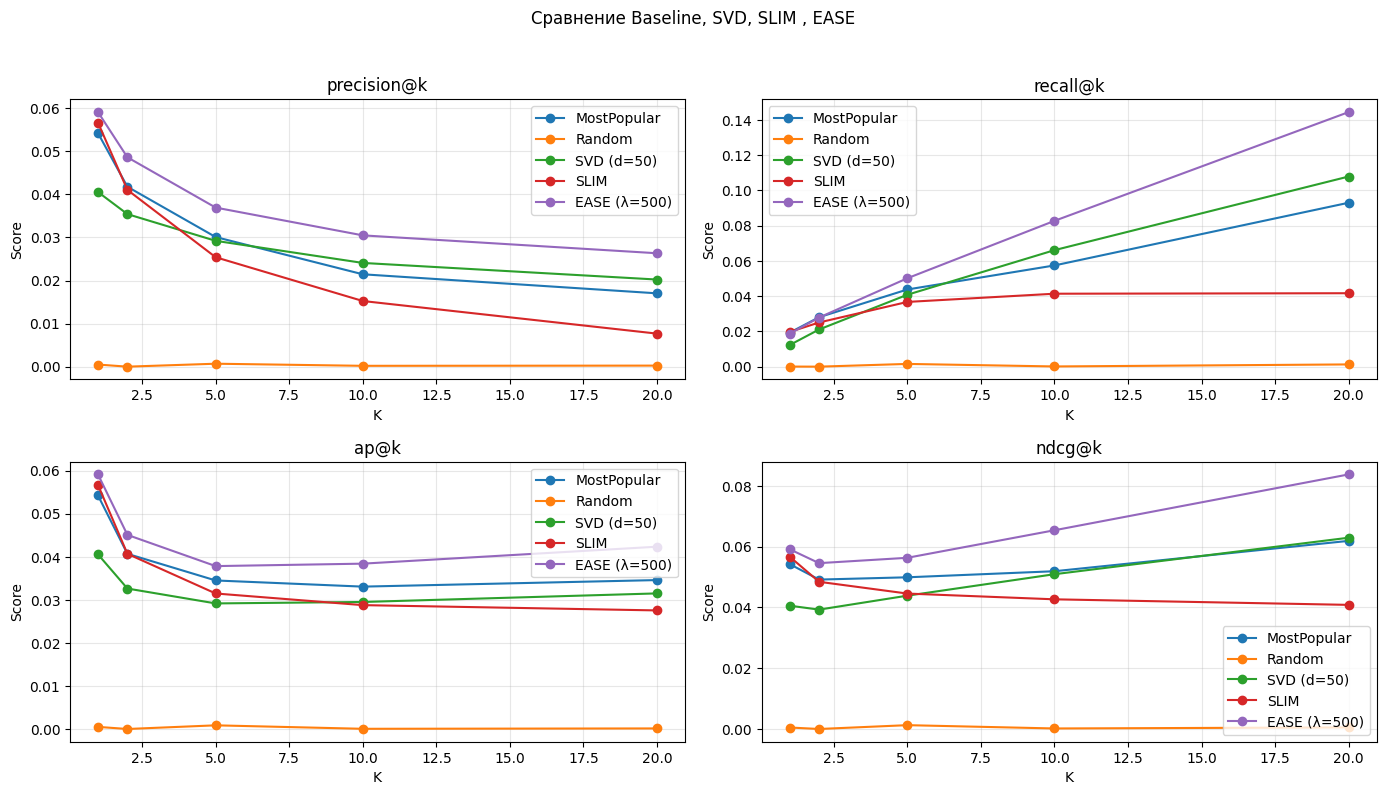

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, res[(mm, "popular")], "-", marker="o", label="MostPopular")
    ax[j].plot(ks, res[(mm, "random")], "-", marker="o", label="Random")
    ax[j].plot(ks, m[50][mm], "-", marker="o", label="SVD (d=50)")
    ax[j].plot(ks, slim_results[mm], "-", marker="o", label="SLIM")
    ax[j].plot(ks, ease[500.0][mm], "-", marker="o", label="EASE (λ=500)")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel("Score")
    ax[j].grid(True, alpha=0.3)
    ax[j].legend(loc="best")
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Сравнение Baseline, SVD, SLIM , EASE", y=1.02)
fig.tight_layout(pad=1.2, rect=(0, 0.03, 1, 1))
plt.show()

## SANSA (Scalable Approximate NonSymmetric Autoencoder)

EASE обучается очень быстро и дает высокое качество, но сталкивается с "бутылочным горлышком" при росте количества товаров. Матрица весов $B$ в EASE получается плотной  — в ней почти нет нулей. Если у нас десятки тысяч товаров, хранение и умножение такой матрицы требует огромного количества памяти ($O(n^2)$) и времени.

Здесь на сцену выходит SANSA. Этот метод сохраняет математическую логику EASE, но использует приближенные вычисления (разреженное разложение Холецкого), чтобы итоговая матрица весов оставалась разреженной, как в SLIM. Это позволяет масштабировать подход EASE на огромные каталоги.

SANSA решает главную проблему EASE — масштабируемость.
В EASE матрица $B$ является плотной, что приводит к огромным затратам памяти и времени при большом количестве предметов. SANSA предлагает метод для эффективного приближения EASE с сохранением разреженности матрицы весов.

**Метод приближения:**
Вместо явного обращения огромной матрицы $P = X^T X + \lambda I$, SANSA использует разреженное разложение Холецкого:
$$P \approx L D L^T$$
где $L$ — нижняя треугольная разреженная матрица.

**Вычисление весов:**
Приближенная обратная матрица выражается через решение систем линейных уравнений с разреженными треугольными матрицами, что позволяет избежать плотных вычислений. Итоговая матрица весов $B$ получается разреженной, что позволяет работать с каталогами из десятков и сотен тысяч товаров.

**Задание 6 (2 балла):** Воспользуйтесь библиотекой [SANSA](https://pypi.org/project/sansa/) и финализируйте эксперименты метриками этой модели

**Ответ:**
SANSA по всем метрикам хуже EASE на всех К. Но лучше SVD, SLIM и наиболее популярныых фильмах по recall@K и ndcg@K. При небольших K < 5 SLIM и наиболее популярные рекомендации чуть лучше  по precision@K и ap@K. В итоге SANSA проще масштабировать на большие объёмы данных, но по качеству она уступает EASE и не всегда лучше остальных моделей.


In [22]:
!apt-get update -qq
!apt-get install -y -qq libsuitesparse-dev
!pip -q install scikit-sparse
!pip -q install sansa


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../00-libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../01-libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libbtf1:amd64.
Preparing to unpack .../02-libbtf1_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libbtf1:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcamd2:amd64.
Preparing to unpack .../03-libcamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcamd2:amd64 (

In [23]:
from sansa import (
    SANSA, SANSAConfig,
    CHOLMODGramianFactorizerConfig, ICFGramianFactorizerConfig,
    UMRUnitLowerTriangleInverterConfig,
)

In [24]:
class SANSARecommender:
    def __init__(self, l2_lambda=100, density_target=0.05) -> None:
        self.l2_lambda = l2_lambda
        self.density_target = density_target
        self.W = None

    def fit(self, X) -> None:
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)

        fcfg = CHOLMODGramianFactorizerConfig()
        icfg = UMRUnitLowerTriangleInverterConfig(scans=1, finetune_steps=5)
        cfg = SANSAConfig(l2=self.l2_lambda, weight_matrix_density=self.density_target,
                         gramian_factorizer_config=fcfg, lower_triangle_inverter_config=icfg)

        self.m = SANSA(cfg)
        self.m.fit(X)

        w1, w2 = self.m.weights
        self.W = (w1 + w2).tocsr()

    def predict(self, X_user: np.ndarray) -> np.ndarray:
        return X_user @ self.W


                For low desired desired (5.000000%), computing exact factorization (CHOLMOD) 
                followed by sparsification may be inefficient.
                You may want to try ICFGramianFactorizer instead of CHOLMODGramianFactorizer 
                (requires less memory and may be faster).
                


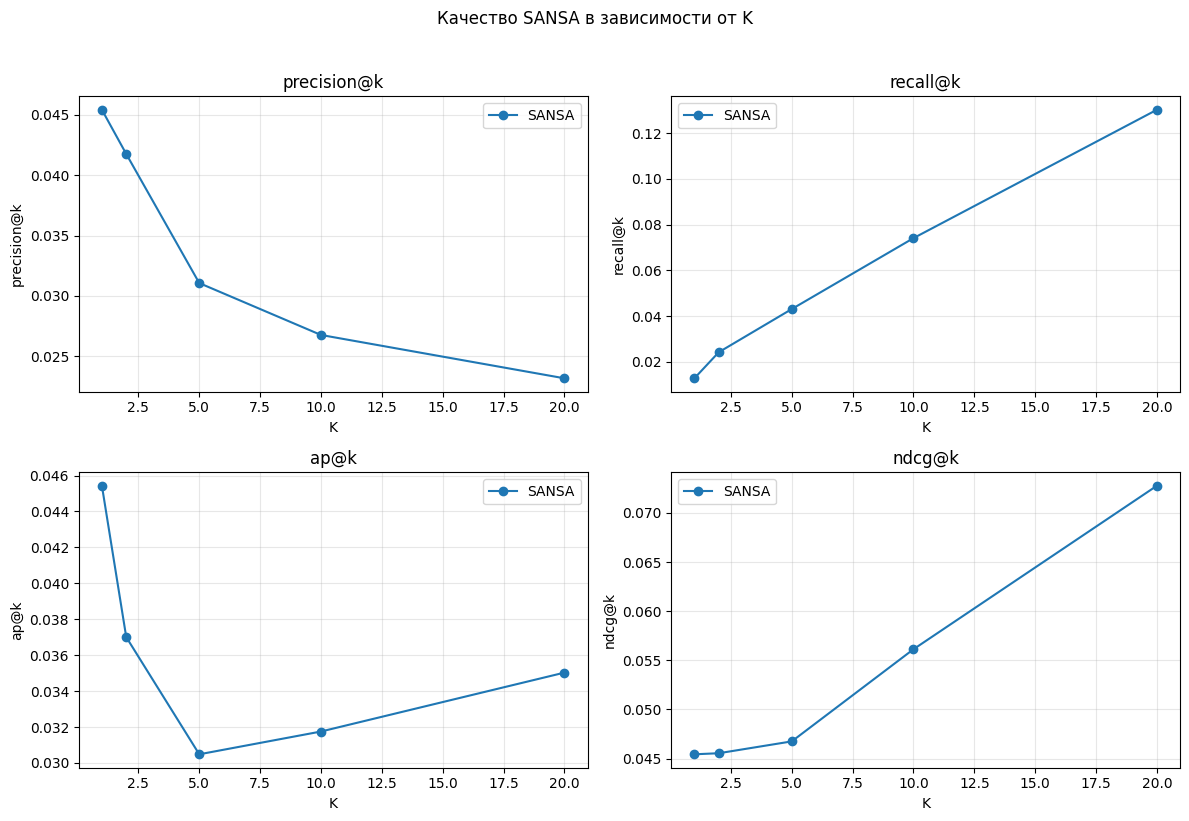

((11916, 11916), 14007081, 0.09864762890417549)

In [25]:
sa = SANSARecommender(l2_lambda=500, density_target=0.05)
sa.fit(X_any)
sc = sa.m.forward(X_any).tocsr()
sc[tr.u.to_numpy(), tr.i.to_numpy()] = -1e9
sc.eliminate_zeros()
ks = [1, 2, 5, 10, 20]
ms = ["precision@k", "recall@k", "ap@k", "ndcg@k"]
rr = {mm: [] for mm in ms}
for k in ks:
    s = {mm: 0.0 for mm in ms}
    c0 = 0
    for uu, r_it in rel.items():
        su = sc.getrow(uu).toarray().ravel()
        idx = np.argpartition(-su, k - 1)[:k]
        idx = idx[np.argsort(-su[idx])]
        a = evaluate_recommender(idx, r_it, k)
        for mm in ms:
            s[mm] += a[mm]
        c0 += 1
    for mm in ms:
        rr[mm].append(s[mm] / c0)
fig, ax = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, rr[mm], marker="o", label="SANSA")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel(mm)
    ax[j].grid(True, alpha=0.3)
    ax[j].legend()
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Качество SANSA в зависимости от K", y=1.02)
sansa_results = {k: list(v) for k, v in rr.items()}
fig.tight_layout()
plt.show()

sa.W.shape, sa.W.nnz, sa.W.nnz / (sa.W.shape[0] * sa.W.shape[1])


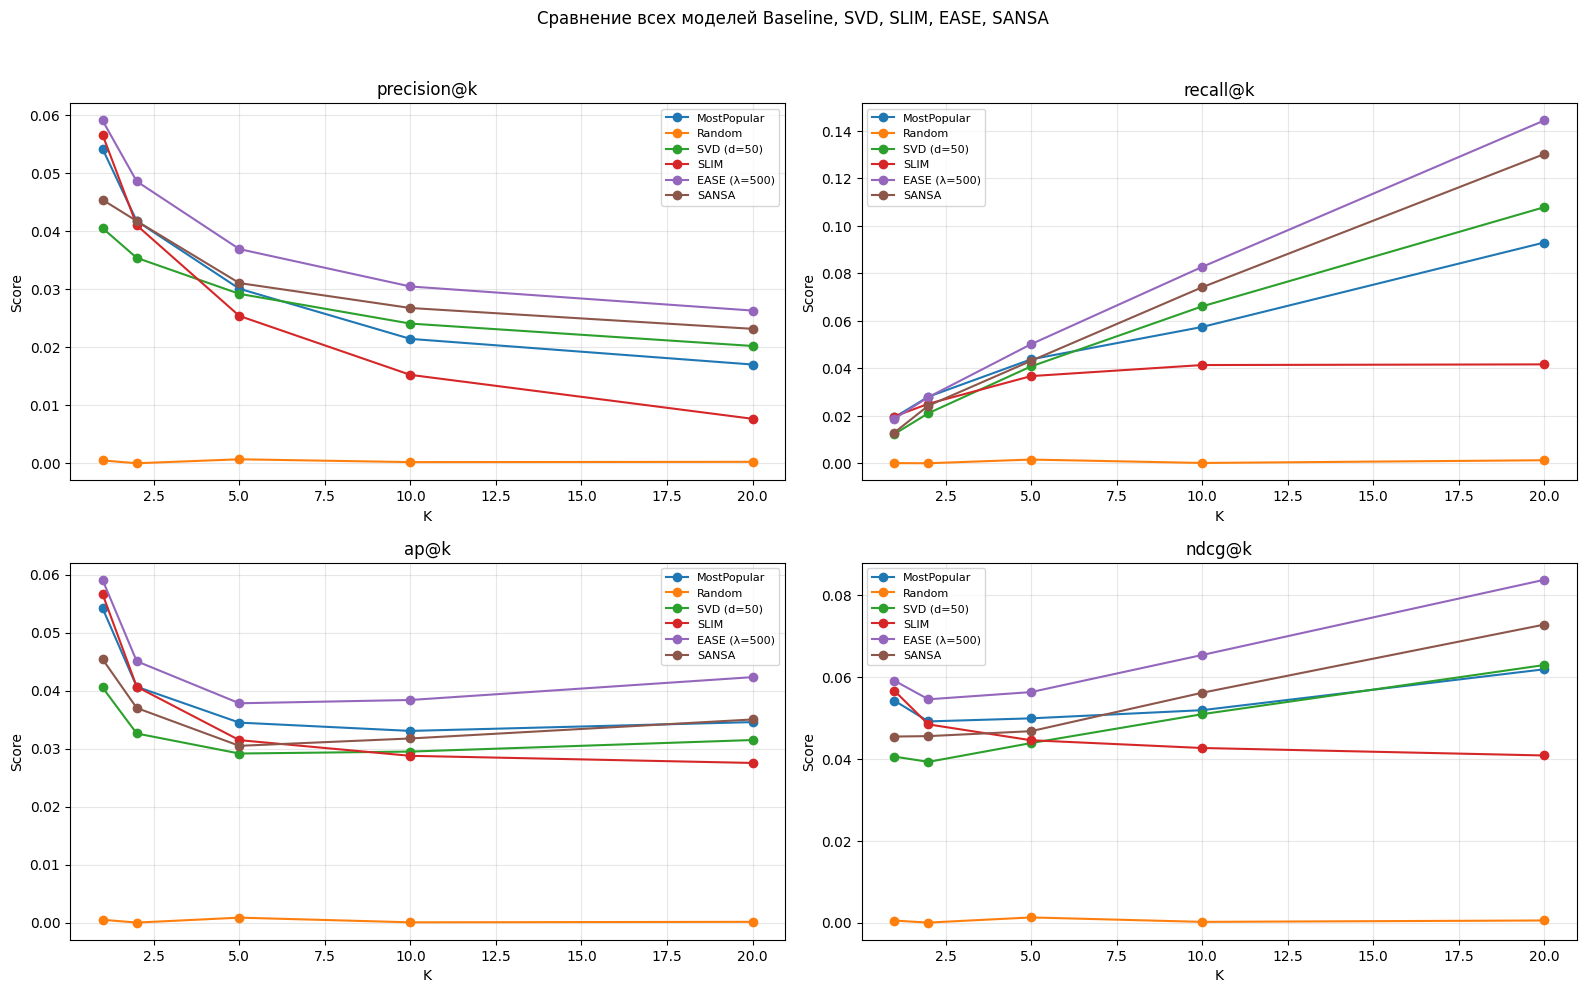

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
ax = ax.ravel()
for j, mm in enumerate(ms):
    ax[j].plot(ks, res[(mm, "popular")], "-", marker="o", label="MostPopular")
    ax[j].plot(ks, res[(mm, "random")], "-", marker="o", label="Random")
    ax[j].plot(ks, m[50][mm], "-", marker="o", label="SVD (d=50)")
    ax[j].plot(ks, slim_results[mm], "-", marker="o", label="SLIM")
    ax[j].plot(ks, ease[500.0][mm], "-", marker="o", label="EASE (λ=500)")
    ax[j].plot(ks, sansa_results[mm], "-", marker="o", label="SANSA")
    ax[j].set_title(mm)
    ax[j].set_xlabel("K")
    ax[j].set_ylabel("Score")
    ax[j].grid(True, alpha=0.3)
    ax[j].legend(loc="best", fontsize=8)
ax[0].tick_params(axis='x', labelbottom=True)
ax[1].tick_params(axis='x', labelbottom=True)
fig.suptitle("Сравнение всех моделей Baseline, SVD, SLIM, EASE, SANSA", y=1.02)
fig.tight_layout(pad=1.2, rect=(0, 0.03, 1, 1))
plt.show()


## Conclusion

В ходе экспериментов были реализованы и сравнены модели SVD, SLIM, EASE и SANSA по метрикам precision@K, recall@K, ap@K и ndcg@K. Лучшее качество показала модель EASE при λ=500,по всем метрикам и на всём диапазоне K. Далее по качесву модель SANSA , если говорить о  K > 5 precision@K и ndcg@K. Модель SLIM дала сопоставимые с SVD результаты на малых K и разреженную, интерпретируемую матрицу item–item коэффициентов, но хуже работает при росте K. Наиболее попоулярные фильмы находятся примерно между SLIM и SVD, все модели превосходят случайные рекомендаций, что логично. ПО итогу EASE лучший по качеству, SANSA второй, SLIM компромисс между качеством и разреженностью, SANSA предпочтительна при ограничениях по ресурсам и необходимости масштабирования на большие объёмы данных.